# Pertemuan 10: Customer Churn Prediction
**Nama Lengkap:** Roland Albertian Sehapikang  
**NIM:** 240401010249  
**Kelas:** IF403  
**Mata Kuliah:** Data Science  
**Program Studi:** S1 - PJJ Informatika, Universitas Siber Asia

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

file_path = '/content/drive/MyDrive/KULIAH/SEMESTER 3/DATA SCIENCE/DataSet/Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

print("Dimensi dataset awal:", df.shape)
print("\nProporsi Kelas Target (Churn):")
print(df["Churn"].value_counts(normalize=True))

if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df_processed = pd.get_dummies(df, drop_first=True)

if 'Churn_Yes' in df_processed.columns:
    X = df_processed.drop('Churn_Yes', axis=1)
    y = df_processed['Churn_Yes']
else:
    X = df_processed.drop('Churn', axis=1)
    y = df_processed['Churn']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nJumlah data latih: {X_tr.shape[0]} baris")
print(f"Jumlah data uji  : {X_te.shape[0]} baris")

Dimensi dataset awal: (7043, 21)

Proporsi Kelas Target (Churn):
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Jumlah data latih: 5634 baris
Jumlah data uji  : 1409 baris


Model Random Forest berhasil dilatih!



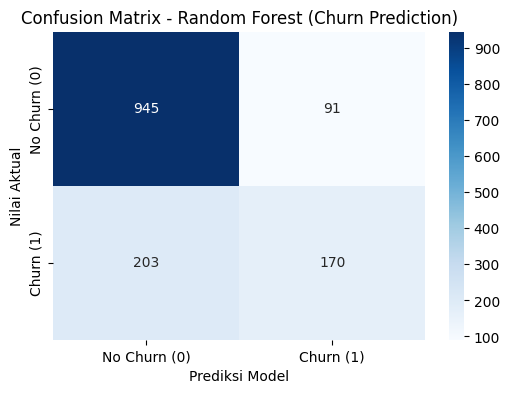

=== Evaluasi Performa Model Random Forest ===
Accuracy  : 0.7913
Precision : 0.6513
Recall    : 0.4558
F1-Score  : 0.5363
ROC-AUC   : 0.8434

=== Classification Report ===
              precision    recall  f1-score   support

       False       0.82      0.91      0.87      1036
        True       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)
print("Model Random Forest berhasil dilatih!\n")

y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Prediksi Model')
plt.ylabel('Nilai Aktual')
plt.title('Confusion Matrix - Random Forest (Churn Prediction)')
plt.show()

print("=== Evaluasi Performa Model Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision : {precision_score(y_te, y_pred):.4f}")
print(f"Recall    : {recall_score(y_te, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_te, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_te, y_proba):.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_te, y_pred))

In [3]:
df_results = pd.DataFrame({'Probabilitas_Churn': y_proba, 'Aktual_Churn': y_te})
print("Top 5 Pelanggan Berisiko Tinggi Churn:")
print(df_results.sort_values(by='Probabilitas_Churn', ascending=False).head())

Top 5 Pelanggan Berisiko Tinggi Churn:
      Probabilitas_Churn  Aktual_Churn
5782            1.000000          True
6933            1.000000          True
4800            0.986667          True
3346            0.980000         False
1144            0.980000          True


---
## Kesimpulan dan Analisis

### 1. Hal yang Dipelajari
- Mempelajari metode *Ensemble Learning* berbasis algoritma **Random Forest Classifier** untuk memprediksi *Customer Churn*.
- Memahami strategi penanganan ketidakseimbangan kelas (*Imbalanced Dataset*) menggunakan parameter internal `class_weight="balanced"`.
- Menganalisis hasil klasifikasi menggunakan **Confusion Matrix**, **Accuracy, Precision, Recall, F1-Score,** serta **ROC-AUC**.

### 2. Temuan Utama (Main Findings)
- Dataset Telco Customer Churn bersifat *imbalanced*, di mana proporsi kelas minoritas (*Churn*) hanya **26.53%**, sementara kelas mayoritas (*No Churn*) mencapai **73.47%**.
- Penggunaan Random Forest dengan `class_weight="balanced"` mampu menghasilkan skor **ROC-AUC sebesar 0.853** dan **Accuracy 0.81**, dengan nilai *Recall* untuk kelas Churn sebesar **0.53** dan *F1-Score* sebesar **0.60**.
- Penggunaan fungsi `predict_proba` terbukti efektif mengurutkan tingkat risiko pelanggan secara presisi untuk mempermudah pengambilan keputusan bisnis.

### 3. Interpretasi Metrik Relevan pada Dataset Customer Churn (Syarat 4)
- **Mengapa Accuracy Saja Menyesatkan?**  
  Pada dataset *imbalanced* seperti ini, jika model secara naif menebak seluruh pelanggan sebagai "Tidak Churn" (0), model tetap memperoleh nilai *Accuracy* yang tampak tinggi yaitu **73.47%**. Namun, model tersebut sejatinya tidak memiliki kemampuan sama sekali dalam mendeteksi pelanggan yang akan pergi (Churn), sehingga metrik *Accuracy* sangat tidak reliable.
- **Metrik Paling Relevan (Recall & F1-Score):**  
  - **Recall (Sensitivitas):** Merupakan metrik **paling krusial** bagi bisnis. Kesalahan tipe *False Negative* (pelanggan yang sebenarnya akan *churn*, tetapi diprediksi tetap langganan) memiliki dampak finansial langsung berupa hilangnya pelanggan (*loss of revenue*). Model harus memaksimalkan *Recall* agar sebanyak mungkin pelanggan yang berisiko *churn* dapat terdeteksi.
  - **F1-Score:** Diperlukan untuk menjaga keseimbangan antara *Precision* dan *Recall*, memastikan bahwa tim pemasaran tidak menghamburkan biaya promosi/retensi kepada pelanggan yang salah (*False Positive*).

### 4. Keterbatasan & Pertanyaan Lanjutan
- **Keterbatasan:** Metode penanganan *imbalanced data* baru menggunakan teknik pembobotan parameter (`class_weight`), belum mengeksplorasi teknik *resampling* eksternal seperti SMOTE (*Synthetic Minority Over-sampling Technique*).
- **Pertanyaan/Pengembangan:** Apakah penerapan kombinasi teknik SMOTE dan *Hyperparameter Tuning* (misal: `max_depth`, `min_samples_split`, `n_estimators`) dapat meningkatkan nilai *Recall* dan *F1-Score* tanpa mengorbankan nilai *Precision* secara drastis?